<a href="https://colab.research.google.com/github/mcasber/Data-Analyst-Portfolio/blob/main/Analytics_activos_Empresa_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de Activos "Empresa"

Preguntas:

1. ¿Hay registros duplicados y campos null?  
2. ¿Cuántos equipos activos hay por Gerencia?
3. ¿Cuántos y cuales tienen RFID?
4. ¿Qué tipo de equipos son (Workstations, Notebooks, etc.) y qué procesador tienen?

Este notebook realiza un análisis exploratorio de datos (EDA) y una preparación de datos (ETL) sobre los activos (equipos y accesorios) de Agea, consolidando información de varias fuentes.

### **Objetivos Principales:**

1.  **Limpieza y Consolidación de Datos**: Unificar diferentes reportes de activos (.xls) y enriquecerlos con información adicional de `SummaryData.csv`.
2.  **Identificación de Datos Faltantes y Duplicados**: Analizar y gestionar valores `null` en campos clave como `serial`, `ubicación`, `dueño`, `gerencia`, `departamento` y `activo_fijo`.
3.  **Clasificación de Activos**: Agrupar los activos en categorías lógicas (Gerencias/Grupos) basándose en la información disponible (`ubicación`, `gerencia`, `departamento`).
4.  **Análisis de RFID**: Determinar cuántos y qué tipo de equipos tienen un identificador RFID.
5.  **Análisis de Workstations y Notebooks**: Identificar los tipos de estos equipos y sus procesadores, así como la cantidad que se encuentra en stock.

### **Pasos Realizados:**

*   **Carga de Datos**: Los datos se cargaron desde archivos `.xls` (interpretados como HTML encapsulado) y un `.csv`.
*   **ETL (Extract, Transform, Load)**:
    *   Normalización de encabezados de columnas.
    *   Concatenación de DataFrames.
    *   Manejo de valores `null`: Completando `serial` con `id`, eliminando registros con `dueño` nulo y reemplazando `null` y '0.00' por 'NO' en `activo_fijo`.
    *   Creación de la columna `rfid` (1 si tiene RFID, 0 si no).
    *   Eliminación de registros de 'Bajas', 'Ventas' y 'Donaciones'.
*   **Agrupación y Clasificación**: Creación de la columna `data_grupo` combinando `ubicación`, `gerencia` y `departamento`, y luego aplicando expresiones regulares para clasificar los activos en grupos como 'SISTEMAS', 'REDACCION', 'COMERCIAL', 'RRHH', etc.
*   **Análisis Específico**: Filtrado y análisis de equipos tipo 'Workstations' y 'Notebooks' para identificar sus procesadores (i3, i5, i7, i9, M1, M2).

### **Resultados Clave:**

*   **Integridad de Datos**: Se logró una base de datos consolidada con manejo de nulos y duplicados.
*   **Distribución por Grupos**: Se visualizó la distribución de activos por las gerencias/grupos definidos.
*   **Inventario en Stock**: Se identificó la cantidad de equipos en stock (LOGISTICA MICROINFORMATICA, STOCK LOGISTICA).
*   **RFID**: Se cuantificaron los equipos con y sin RFID, y se observaron los tipos de equipos con RFID.
*   **Especificaciones de Hardware**: Se extrajo y contabilizó información sobre el tipo de procesador en Workstations y Notebooks.

#Nota
**"Nota: El dataset original es privado por acuerdos de confidencialidad. Se muestra la lógica de procesamiento y análisis aplicada sobre datos reales anonimizados."**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ETL I data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
otros = pd.read_html('/content/drive/MyDrive/Agea_analytics_activos/Asset_Summary_Report_otros.xls') #lo cargamos como html
perifericos = pd.read_html('/content/drive/MyDrive/Agea_analytics_activos/Asset_Summary_Report_perifericos.xls')
raw_print_data = pd.read_html('/content/drive/MyDrive/Agea_analytics_activos/Asset_Summary_Report_print.xls')
workstations = pd.read_html('/content/drive/MyDrive/Agea_analytics_activos/Asset_Summary_Report_workstations.xls')

Nota: utilizamos read_html porque el formato del .xls era un HTML encapsulado.

In [ ]:
type(perifericos)

list

In [ ]:
perifericos


In [ ]:
#El DataFrame df_asset_summary tiene la primera fila como encabezado. Necesitamos establecer esa fila como los nombres de las columnas y luego limpiar esos nombres.
#Y nos quedamos con la primera posicion del df
df_otros = otros[0]
df_perifericos = perifericos[0]
df_print = raw_print_data[0]
df_workstations = workstations[0]

In [ ]:
#veamos los shape
df_otros.shape, df_perifericos.shape, df_print.shape, df_workstations.shape


((169, 7), (5551, 7), (411, 7), (4542, 7))

In [ ]:
# Establecer la primera fila como encabezado y luego eliminarla para los df_...
df_otros.columns = df_otros.iloc[0]
df_otros = df_otros[1:].reset_index(drop=True)

df_perifericos.columns = df_perifericos.iloc[0]
df_perifericos = df_perifericos[1:].reset_index(drop=True)

df_print.columns = df_print.iloc[0]
df_print = df_print[1:].reset_index(drop=True)

df_workstations.columns = df_workstations.iloc[0]
df_workstations = df_workstations[1:].reset_index(drop=True)

In [ ]:
# Normalizar los nombres de las columnas (convertir a minúsculas, reemplazar espacios por guiones bajos, eliminar espacios en blanco)
for df in [df_otros, df_perifericos, df_print, df_workstations]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Display df_otros to show the changes
df_otros

,id,tipo,marca,modelo,serial,ubicación,dueño
0,12D5ND4,PC DE ESCRITORIO,DELL,PRO MICRO ( DELL 2025 ),12D5ND4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
1,14MNPD4,NOTEBOOKS,DELL,PERFIL ADMINISTRATIVO N° 4,14MNPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
2,15MNPD4,NOTEBOOKS,DELL,PERFIL ADMINISTRATIVO N° 4,15MNPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
3,1LJQPD4,NOTEBOOKS,DELL,STANDARD,1LJQPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
4,1MJQPD4,NOTEBOOKS,DELL,STANDARD,1MJQPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
...,...,...,...,...,...,...,...
163,JMJQPD4,NOTEBOOKS,DELL,STANDARD,JMJQPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
164,JSJQPD4,NOTEBOOKS,DELL,STANDARD,JSJQPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
165,JTJQPD4,NOTEBOOKS,DELL,STANDARD,JTJQPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA
166,JVJQPD4,NOTEBOOKS,DELL,STANDARD,JVJQPD4,LOGISTICA MICROINFORMATICA,STOCK LOGISTICA


In [ ]:
df_otros.info()
df_perifericos.info()
df_print.info()
df_workstations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         168 non-null    object
 1   tipo       168 non-null    object
 2   marca      168 non-null    object
 3   modelo     168 non-null    object
 4   serial     168 non-null    object
 5   ubicación  168 non-null    object
 6   dueño      168 non-null    object
dtypes: object(7)
memory usage: 9.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5550 entries, 0 to 5549
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         5550 non-null   object
 1   tipo       5550 non-null   object
 2   marca      5550 non-null   object
 3   modelo     5550 non-null   object
 4   serial     5504 non-null   object
 5   ubicación  4903 non-null   object
 6   dueño      5550 non-null   object
dtypes: object(7)
memory usage: 303.6+ KB
<class

##Uniones

In [ ]:
#los unimos con concat
df_concat=pd.concat([df_otros, df_perifericos, df_print, df_workstations],ignore_index=True)

In [ ]:
df_concat.shape

(10669, 7)

##EDA

In [ ]:
df_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10669 entries, 0 to 10668
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         10669 non-null  object
 1   tipo       10669 non-null  object
 2   marca      10669 non-null  object
 3   modelo     10669 non-null  object
 4   serial     10622 non-null  object
 5   ubicación  9793 non-null   object
 6   dueño      10631 non-null  object
dtypes: object(7)
memory usage: 583.6+ KB


In [ ]:
#vemos los nulos
df_concat.isnull().sum()

,0
0,
id,0
tipo,0
marca,0
modelo,0
serial,47
ubicación,876
dueño,38


In [ ]:
#vemos los owner nulos
df_concat[df_concat[['dueño']].isnull().any(axis=1)]

,id,tipo,marca,modelo,serial,ubicación,dueño
9358,C_CGA_ABLAS_NWX,Workstation Online,Dell Inc.,Latitude 5420,C0JL9C3,NaN,NaN
9359,C_TF_AROTAS_PWX,Workstation Online,Dell Inc.,OptiPlex 7040,GMZHHH2,NaN,NaN
9360,C_TF_CPIZZ_PWX,Workstation Online,Dell Inc.,OptiPlex 780,5D1ZGQ1,NaN,NaN
9361,C_VNO_GAROF_NWX,Workstation Online,Dell Inc.,Latitude E5470,1726KC2,NaN,NaN
10519,R_ARE_CREIN_PW7,Workstation Online,Dell Inc.,OptiPlex 755,5GRDBF1,NaN,NaN
10520,R_ARE_MAURI_PW7,Workstation Online,Dell Inc.,OptiPlex 7010,84P0022,NaN,NaN
10521,R_COM_HMARM_PWX,Workstation Online,Dell Inc.,OptiPlex 7060,G2NB0W2,NaN,NaN
10522,R_COM_MPAPA_PWX,Workstation Online,Dell Inc.,OptiPlex 7060,9BCGHV2,NaN,NaN
10523,R_DEP_MVERR_PWX,Workstation Online,American Megatrends Inc.,Ready C2 - Style C2,1086132A00002,NaN,NaN
10525,R_FOT_WKS12_PW7,Workstation Online,Dell Inc.,OptiPlex 7010,4W49S22,NaN,NaN


In [ ]:
#duplicados
df_concat.duplicated().sum()

np.int64(0)

Vemos de ordenarlo por owner para tener idea de que rows corresponden a bajas, ventas, etc.

In [ ]:
df_concat.groupby('dueño')['serial'].count().sort_values(ascending=False).reset_index().head(10)

,dueño,serial
0,BAJAS,2766
1,LOGISTICA MICROINFORMATICA,1153
2,VENTA,907
3,STOCK LOGISTICA,467
4,RETIRAR / RECUPERAR DEL PUESTO,451
5,STOCK AUDIOVISUAL REDACCION,178
6,STOCK TV Y VIDEO SOPORTE,160
7,STOCK SOPORTE ZEPITA,66
8,SOPORTE ZEPITA,65
9,BAJA TEKNARIA,61


#ETL 2 | para adicionar data
De aca vamos a tomar las column 'Gerencia', 'Departamento' ,'Activo Fijo'(rfid) y el id para matchear.


In [ ]:
#Nota SummaryData.csv | ACTUALIZADO 08/01/2026
etl2=pd.read_csv('/content/drive/MyDrive/Agea_analytics_activos/SummaryData.csv',sep=',',skiprows=1, encoding='latin1')

In [ ]:
etl2.columns

Index(['ID', 'Marca', 'Modelo', 'Nro. de Serie', 'Observaciones', 'Activo',
       'Ubicación', 'Dueño', 'Inventario', 'Fecha Adquisición', 'Factura',
       'Ord. Compra N°', 'Gerencia', 'Departamento', 'Empresa',
       'Centro de Costo', 'Proveedor', 'Tipo Adquisición',
       'Fecha Finalización', 'Importe', 'Porc. de Depreciación',
       'Exp. Garantía', 'Detalles Gtía.', 'Activo Fijo', 'Método de Pago'],
      dtype='object')

In [ ]:
#Nos quedamos con las columnas
etl2=etl2[['ID','Gerencia', 'Departamento', 'Activo Fijo']]
#normalizamos
etl2.columns = etl2.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
etl2.duplicated().sum()

np.int64(0)

In [ ]:
etl2.isnull().sum()

,0
id,0
gerencia,4664
departamento,5027
activo_fijo,6140


In [ ]:
etl2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10634 entries, 0 to 10633
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10634 non-null  object
 1   gerencia      5970 non-null   object
 2   departamento  5607 non-null   object
 3   activo_fijo   4494 non-null   object
dtypes: object(4)
memory usage: 332.4+ KB


#Uniones II

In [ ]:
#Ahora unimos las 2 bases por el id
df_concat.shape, etl2.shape

((10669, 7), (10634, 4))

In [ ]:
#como df_concat tiene mas registros realizaremos un merge priorizando esta
df_final=pd.merge(df_concat,etl2,how='left',on='id')

In [ ]:
df_final.shape

(10669, 10)

In [ ]:
df_final.sample()

,id,tipo,marca,modelo,serial,ubicación,dueño,gerencia,departamento,activo_fijo
6881,3ZZNJH1,Workstation Offline,DELL,Optiplex 755,3ZZNJH1,BAJAS,BAJAS,GCIA DE SISTEMAS,NaN,NaN


#EDA df_final

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10669 entries, 0 to 10668
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10669 non-null  object
 1   tipo          10669 non-null  object
 2   marca         10669 non-null  object
 3   modelo        10669 non-null  object
 4   serial        10622 non-null  object
 5   ubicación     9793 non-null   object
 6   dueño         10631 non-null  object
 7   gerencia      5959 non-null   object
 8   departamento  5597 non-null   object
 9   activo_fijo   4493 non-null   object
dtypes: object(10)
memory usage: 833.6+ KB


#1.¿Hay registros duplicados y campos null?

In [ ]:
df_final.duplicated().sum()

np.int64(0)

In [ ]:
df_final.isnull().sum()

,0
id,0
tipo,0
marca,0
modelo,0
serial,47
ubicación,876
dueño,38
gerencia,4710
departamento,5072
activo_fijo,6176


#Documentar y definir acciones

* sin duplicados

* nulos:

serial	47: seguramente sea el id el serial, ubicarlos y verificarlos

ubicación	876: utilizar data existente para completar 'gerencia'

dueño	38: ubicarlos y ver de completar

gerencia	4710: ver de completar con data de ubicacion|departameto

departamento	5072: utilizar data existente para completar 'gerencia'

activo_fijo	6176: es el rfid, ver cuales son y sumar los que estan en '0.00'




##serial

In [ ]:
#vemos los serial nan
df_final[df_final[['serial']].isnull().any(axis=1)].sample(3)

,id,tipo,marca,modelo,serial,ubicación,dueño,gerencia,departamento,activo_fijo
1288,123400004,DOCK STATION,SATECHI,USB-C,NaN,AUDIOVISUAL CLARIN,STOCK AUDIOVISUAL REDACCION,REDACCION CLARIN,AUDIOVISUAL CLARIN,NaN
5562,TKT170497,DOCK STATION,DELL,E-PORT PLUS - USB 3.0,NaN,BAJAS,BAJAS,NaN,NaN,0.00
2919,7BF-25RA,MONITOR,DELL,17,NaN,DONACIONES,DONACION,NaN,NaN,0.00


In [ ]:
#los completamos con el id
df_final['serial'].fillna(df_final['id'], inplace=True)

/tmp/ipython-input-1298689810.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['serial'].fillna(df_final['id'], inplace=True)


##dueño

In [ ]:
#vemos los dueños null
df_final[df_final[['dueño']].isnull().any(axis=1)].head(40)


,id,tipo,marca,modelo,serial,ubicación,dueño,gerencia,departamento,activo_fijo
9358,C_CGA_ABLAS_NWX,Workstation Online,Dell Inc.,Latitude 5420,C0JL9C3,NaN,NaN,NaN,NaN,NaN
9359,C_TF_AROTAS_PWX,Workstation Online,Dell Inc.,OptiPlex 7040,GMZHHH2,NaN,NaN,NaN,NaN,NaN
9360,C_TF_CPIZZ_PWX,Workstation Online,Dell Inc.,OptiPlex 780,5D1ZGQ1,NaN,NaN,NaN,NaN,NaN
9361,C_VNO_GAROF_NWX,Workstation Online,Dell Inc.,Latitude E5470,1726KC2,NaN,NaN,NaN,NaN,NaN
10519,R_ARE_CREIN_PW7,Workstation Online,Dell Inc.,OptiPlex 755,5GRDBF1,NaN,NaN,NaN,NaN,NaN
10520,R_ARE_MAURI_PW7,Workstation Online,Dell Inc.,OptiPlex 7010,84P0022,NaN,NaN,NaN,NaN,NaN
10521,R_COM_HMARM_PWX,Workstation Online,Dell Inc.,OptiPlex 7060,G2NB0W2,NaN,NaN,NaN,NaN,NaN
10522,R_COM_MPAPA_PWX,Workstation Online,Dell Inc.,OptiPlex 7060,9BCGHV2,NaN,NaN,NaN,NaN,NaN
10523,R_DEP_MVERR_PWX,Workstation Online,American Megatrends Inc.,Ready C2 - Style C2,1086132A00002,NaN,NaN,NaN,NaN,NaN
10525,R_FOT_WKS12_PW7,Workstation Online,Dell Inc.,OptiPlex 7010,4W49S22,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_final.query('serial=="C0JL9C3"')

Ver esto, son equipos que al re-conectarse generaron nuevo id y duplican el serial dejando el dueño nan | => los eliminamos

In [ ]:
#y eliminamos los NaN del campo 'dueño'
df_final.dropna(subset=['dueño'], inplace=True)

##activo_fijo

In [ ]:
rfid=df_final['activo_fijo'].value_counts().reset_index()
rfid

,activo_fijo,count
0,0.00,3441
1,450444,2
2,20005A1E,2
3,20005A33,2
4,20001DAD,2
...,...,...
1043,200059FF,1
1044,20007FA4,1
1045,20005A4F,1
1046,2000807C,1


In [ ]:
#vemos los duplicados
rfid.query('count >= 2')

,activo_fijo,count
0,0.00,3441
1,450444,2
2,20005A1E,2
3,20005A33,2
4,20001DAD,2


In [ ]:
#vemos cuales son:
df_final.query('activo_fijo=="450444"')

In [ ]:
#completamos con 'NO' los null
df_final['activo_fijo'].fillna('NO', inplace=True)

/tmp/ipython-input-3303375660.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['activo_fijo'].fillna('NO', inplace=True)


In [ ]:
#y los 0.00 tambien los cambiamos por NO
df_final['activo_fijo'].replace('0.00', 'NO', inplace=True)

In [ ]:
#y con esto vemos la cantidad total que no tiene rfid
df_final['activo_fijo'].value_counts()

,count
activo_fijo,
NO,9580
450444,2
20005A1E,2
20005A33,2
20001DAD,2
...,...
200059FF,1
20007FA4,1
20005A4F,1


In [ ]:
#y generamos la column rfid con valor 1 para los que son distintos de NO
df_final['rfid']=df_final['activo_fijo'].apply(lambda x: 1 if x!='NO' else 0)


In [ ]:
#vemos como se distribuyen
df_final['rfid'].value_counts()

,count
rfid,
0,9580
1,1051


##Grupo | Gerencia
Para completar a que grupo pertenecen y como faltan muchos datos en estos campos, vamos a generar un campo nuevo con la data de: ubicación|gerencia|departamento.
Para luego en base a esto generar el grupo al que pertenecen segun su info.


In [ ]:
df_final['data_grupo'] = df_final['ubicación'].fillna('') + ' ' + \
                         df_final['gerencia'].fillna('') + ' ' + \
                         df_final['departamento'].fillna('')

Antes de unirlos, usamos .fillna('') para reemplazar cualquier valor NaN (nulo) con una cadena vacía ''. Esto asegura que los valores nulos no causen que toda la entrada en data_grupo sea NaN.

In [ ]:
df_final.sample(2)

###Eliminamos 'bajas'
Todos los referentes a bajas/ventas/donaciones...

In [ ]:
#identificamos por dueños
bajas_dueno=df_final.loc[df_final['dueño'].str.contains('baja|bajas|venta|ventas|donacion', case=False, na=False, regex=True)]
bajas_dueno.shape


(4003, 12)

In [ ]:
#y los eliminamos
df_final.drop(bajas_dueno.index, inplace=True)

In [ ]:
#identificamos por data 'ubicacion'
bajas_ubicacion=df_final.loc[df_final['data_grupo'].str.contains('baja|bajas|venta|ventas|donacion', case=False, na=False, regex=True)]
bajas_ubicacion.shape


(13, 12)

In [ ]:
#y las eliminamos
df_final.drop(bajas_ubicacion.index, inplace=True)

In [ ]:
#veamos que queda
df_final.shape

(6615, 12)

###Regex para grupos
Comenzamos a agrupar

In [ ]:
df_final.loc[df_final['data_grupo'].str.contains('Sistemas|LOGISTICA|TECNO|operaciones|soporte|sitios|DATA CENTER|telecomunicaciones|UNIX|SIAMM|MESA|TV Y VIDEO',
                                                 case=False, na=False, regex=True), 'data_grupo'] = 'SISTEMAS'

In [ ]:
df_final.loc[df_final['data_grupo'].str.contains('BIG', case=False, na=False, regex=True), 'data_grupo'] = 'BIG DATA'

In [ ]:
df_final.loc[df_final['data_grupo'].str.contains('redaccion|ole|clasificados|ELLE|MESA CENTRAL|VIVA|ENVIADOS|ZONALES|FOTO|CORRESPONSAL|AGENCIA|COLABORAD|TELEM|DIAGRAMACION',
                                                 case=False, na=False, regex=True), 'data_grupo'] = 'REDACCION'

In [ ]:
df_final.loc[df_final['data_grupo'].str.contains('marketing|comercial|digitales|clientes|argenprop|AUTOS|365|OPCIONALES|relacionamiento|SUSCRIPCIONES',
                                                 case=False, na=False, regex=True), 'data_grupo'] = 'COMERCIAL'

In [ ]:
df_final.loc[df_final['data_grupo'].str.contains('CAPITAL HUMANO|BUFFET|COMISION|CONMUTADOR|ELECTRICIDAD|RR.HH|RRHH|MANTENIMIENTO|SEGURIDAD|RECEPCION|CAM|INTENDENCIA|MEDICO|BOMBEROS',
                                                 case=False, na=False, regex=True), 'data_grupo'] = 'RRHH'

In [ ]:
df_final.loc[df_final['data_grupo'].str.contains('PRODUCCION|PLANCHAS|IMPRESION|OSA|ROTATIVAS', case=False, na=False, regex=True), 'data_grupo'] = 'PRODUCCION'
df_final.loc[df_final['data_grupo'].str.contains('ADMINIS|FINANZAS|CREDITOS', case=False, na=False, regex=True), 'data_grupo'] = 'ADMINISTRACION'
df_final.loc[df_final['data_grupo'].str.contains('TINTA FRESCA', case=False, na=False, regex=True), 'data_grupo'] = 'TINTA FRESCA'
df_final.loc[df_final['data_grupo'].str.contains('CIRCULAC|LEVER', case=False, na=False, regex=True), 'data_grupo'] = 'CIRCULACION'

In [ ]:
#Agrupar campos data_grupo vacíos como 'OTROS'
df_final.loc[df_final['data_grupo'].str.strip() == '', 'data_grupo'] = 'OTROS'

###Agrupamos el resto en 'OTROS'

In [ ]:
data_grupo_counts = df_final['data_grupo'].value_counts().reset_index()
otros = data_grupo_counts[data_grupo_counts['count'] <= 11]['data_grupo'].tolist()
print(otros)

['PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL PARQUE  ', 'GERENCIA GENERAL GERENCIA GENERAL GERENCIA GENERAL', 'GCIA GENERAL GERENCIA GENERAL GCIA GENERAL', 'MAR DEL PLATA  ', 'DISTRIBUIDORA DEL PARQUE  ', 'SALA 27 GERENCIA GENERAL SALA 27', 'GCIA GENERAL GERENCIA GENERAL GERENCIA GENERAL', 'BIMO BIMO BIMO', 'GCIA GENERAL GERENCIA GENERAL SALA 27', 'GERENCIA GENERAL  ', 'PLANTA ZEPITA  ', 'MUY  ', 'CLARIN.COM  ', 'VISITAS GUIADAS ZEPITA  ', 'GCIA GENERAL GERENCIA GENERAL ', 'AGL  ', 'BIG DATA', 'GERENCIA GENERAL GERENCIA GENERAL GCIA GENERAL', 'GERENCIA GENERAL GERENCIA GENERAL ', 'DISEÑO GRUPO CLARIN  DISEÑO', 'PCTV en SEO  ', 'USO DOMICILIARIO  ', 'SERVICIOS GENERALES  ', 'DESPACHO DE PRODUCTOS  ', 'LABORATORIO STU  ', 'CLARIN WEB  ', 'PLANTA IMPRESORA TUCUMAN  ', 'SALA DE REUNIONES  ', 'CORDOBA DOMICILIO PARTICULAR  ', 'REVISTA Ñ  ', 'MUJER  ', 'GERENCIAS VARIAS GCIAS VARIAS GCIAS VARIAS', 'GENIOS  ', 'GRUPO CLARIN GRUPO CLARIN  ', 'DIGITAL BUSINNES DBU  ', 'USO DOMICILIARIO BIMO U

In [ ]:
#agrupamos el resto en otros (*luego analizarlos)
df_final.loc[df_final['data_grupo'].isin(otros), 'data_grupo'] = 'OTROS' #mejor urtilizamos el metodo isin() y le pasamos la lista 'otros'

#2.¿Cuántos equipos activos hay por Gerencia?

In [ ]:
df_final['data_grupo'].count()

np.int64(6615)

In [ ]:
#Verificamos los valores únicos y sus conteos después de la estandarización
df_final['data_grupo'].value_counts().reset_index()

,data_grupo,count
0,SISTEMAS,2772
1,REDACCION,2010
2,COMERCIAL,822
3,RRHH,249
4,OTROS,198
5,PRODUCCION,184
6,ADMINISTRACION,179
7,TINTA FRESCA,138
8,CIRCULACION,63


##2.1¿Y cuantos de sistemas son de stock?

In [ ]:
#adicionamos la column stock
#df_final['stock']=df_final['dueño'].apply(lambda x: 1 if x=='STOCK LOGISTICA' or x=='LOGISTICA MICROINFORMATICA' else 0)

In [ ]:
#Esto es más rápido porque es una operación vectorizada de pandas, mientras que apply con una función lambda es un bucle de Python disfrazado.
stock_owners = ['STOCK LOGISTICA', 'LOGISTICA MICROINFORMATICA']
df_final['stock'] = df_final['dueño'].isin(stock_owners).astype(int)

In [ ]:
df_final['stock'].value_counts(),df_final['stock'].count()

(stock
 0    4982
 1    1633
 Name: count, dtype: int64,
 np.int64(6615))

##Una idea grafica

/tmp/ipython-input-3862258295.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


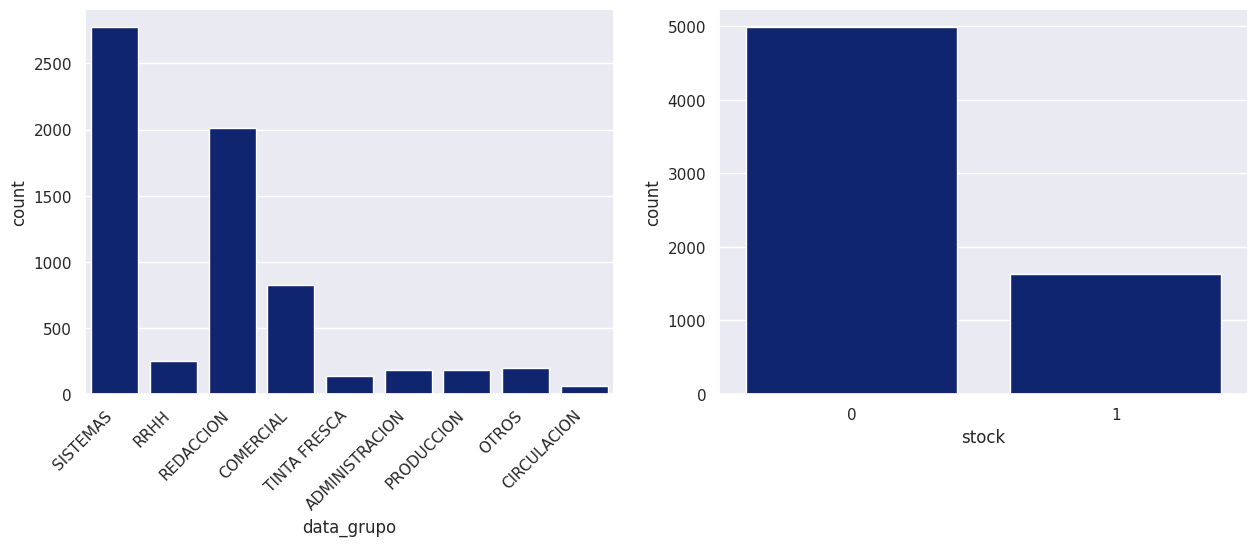

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.set(style='darkgrid',palette='dark')

sns.countplot(data=df_final,
              x='data_grupo',
              ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.countplot(data=df_final,
              x='stock',
              ax=axes[1])
#axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.show()

In [ ]:
#veamos que hay en vacios y otros
df_final.query('data_grupo=="OTROS"').sample(3)


In [ ]:
# VER ESTO --> donde estan estos equipos?
df_final.query('dueño=="PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL PARQUE"').sample(3)

,id,tipo,marca,modelo,serial,ubicación,dueño,gerencia,departamento,activo_fijo,rfid,data_grupo,stock
9312,CR7NVL1,Workstation Offline,DELL,Optiplex 780,CR7NVL1,PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL P...,PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL P...,NaN,NaN,NO,0,OTROS,0
10000,H0TZN22,Workstation Offline,DELL,Optiplex 7010,H0TZN22,PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL P...,PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL P...,NaN,NaN,NO,0,OTROS,0
2412,45L-20DM,MONITOR,DELL,E2214H,45L-20DM,PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL P...,PROYECTO BACKOFFICE DISTRIBUIDORAS JPC Y DEL P...,NaN,NaN,NO,0,OTROS,0


#3.¿Cuántos y cuales tienen RFID?

In [ ]:
df_final.sample(3)
con_rfid=df_final.query('rfid==1')
con_rfid.shape
con_rfid.groupby('tipo')['id'].count()

,id
tipo,
DISCO RIGIDO EXTERNO,3
DOCK STATION,1
LENTE CAMARA FOTOGRAFICA 2,2
PROYECTOR,3
TABLET,3
TELEFONO CELULAR,1
TELEFONO IP,54
Workstation Offline,866


In [ ]:
con_rfid.query('tipo=="TELEFONO IP"')

#Notebooks y PC

In [ ]:
#vemos cuantos tipos tenemos
df_final['tipo'].value_counts()
df_final['tipo'].unique()
#df_final['tipo'].nunique()

array(['PC DE ESCRITORIO', 'NOTEBOOKS', 'TELEVISOR', 'DOCK STATION',
       'Joystick PS4', 'AURICULARES / VINCHAS', 'TELEFONO IP',
       'EQUIPOS ILUMINACION', 'TRIPODE / PALO SELFIE',
       'CAMARA FOTOGRAFICA', 'PROYECTOR', 'MONITOR',
       'BATERIA CAMARA FOTOGRAFICA', 'MOUSE INALAMBRICO', 'SCANNER',
       'KIT TECLADO/MOUSE INALAMBRICO', 'SET BACK BOX', 'TABLET',
       'TELEFONO', 'other', 'PARLANTES PC', 'CALIBRADOR COLOR',
       'MOCHILA/BOLSO/ MORRAL FOTOGRAFICA PROFESIONAL', 'MICROFONO',
       'CAPUCHON DE MICROFONO', 'Pendrive', 'BASE PLEGABLE P/ NOTEBOOK',
       'ROUTER', 'CARGADOR BATERIA FOTOGRAFIA',
       'LENTE CAMARA FOTOGRAFICA', 'WEB CAM', 'DRON',
       'FILTRO FOTOGRAFICO 72MM', 'LENTE CAMARA FOTOGRAFICA 2',
       'CARRY DISK', 'FLASH CAMARA FOTOGRAFICA / OTROS',
       'MICROFONO PARA CAMARA FOTOGRAFICA', 'COOLER PAD', 'Switch',
       'CAMARA DIGITAL', 'TECLADO', 'PLACA DE RED USB / WIFI',
       'RADIO DISPARADOR FLASH', 'DISCO RIGIDO EXTERNO',
       '

In [ ]:
df_final.columns

Index(['id', 'tipo', 'marca', 'modelo', 'serial', 'ubicación', 'dueño',
       'gerencia', 'departamento', 'activo_fijo', 'rfid', 'data_grupo',
       'stock'],
      dtype='object')

In [ ]:
#Nos quedamos con las columnas relevantes
pc_notebook=df_final[['id', 'tipo', 'marca', 'modelo', 'serial', 'data_grupo', 'stock']]

In [ ]:
#Y seleccionamos los tipos que nos interesan
pc_notebook=pc_notebook[pc_notebook['tipo'].isin(['PC DE ESCRITORIO', 'NOTEBOOKS','Workstation Offline', 'Workstation Online'])]

In [ ]:
#vemos los serial duplicados
pc_notebook[pc_notebook.duplicated(subset=['serial'])]
#y los eliminamos
pc_notebook.drop_duplicates(subset=['serial'], inplace=True)

In [ ]:
pc_notebook.sample(3)
pc_notebook.shape
#pc_notbook.query('tipo=="PC DE ESCRITORIO"')

(2306, 7)

Vemos de adicionar un campo con la data del procesador que consigamos

In [ ]:
pc_notebook['procesador']='SIN DATOS'


In [ ]:
#vemos la data que podemos rescatar del procesador
pc_notebook.loc[pc_notebook['modelo'].str.contains('i3', case=False, na=False, regex=True), 'procesador'] = 'i3'
pc_notebook.loc[pc_notebook['modelo'].str.contains('i5', case=False, na=False, regex=True), 'procesador'] = 'i5'
pc_notebook.loc[pc_notebook['modelo'].str.contains('i7', case=False, na=False, regex=True), 'procesador'] = 'i7'
pc_notebook.loc[pc_notebook['modelo'].str.contains('i9', case=False, na=False, regex=True), 'procesador'] = 'i9'
pc_notebook.loc[pc_notebook['modelo'].str.contains('m1', case=False, na=False, regex=True), 'procesador'] = 'M1'
pc_notebook.loc[pc_notebook['modelo'].str.contains('m2', case=False, na=False, regex=True), 'procesador'] = 'M2'

In [ ]:
display(pc_notebook.groupby('procesador')['id'].count().reset_index())

,procesador,id
0,M1,9
1,M2,1
2,SIN DATOS,1833
3,i3,2
4,i5,211
5,i7,249
6,i9,1


#4.¿Qué tipo Notebooks y PC son?
y ¿qué procesador tienen?

In [ ]:
#para este analisis vamos a modificar los tipo 'Workstation Online' a 'Workstation Offline'
pc_notebook.loc[pc_notebook['tipo'] == 'Workstation Online', 'tipo'] = 'Workstation Offline'

In [ ]:
pc_notebook.groupby(['tipo','procesador'])['id'].count() #.sort_values(ascending=False).reset_index()

tipo                 procesador
NOTEBOOKS            SIN DATOS      148
PC DE ESCRITORIO     SIN DATOS       20
Workstation Offline  M1               9
                     M2               1
                     SIN DATOS     1665
                     i3               2
                     i5             211
                     i7             249
                     i9               1
Name: id, dtype: int64

##4.1¿Cuantas son de stock?

In [ ]:
pc_notebook.sample(2)

,id,tipo,marca,modelo,serial,data_grupo,stock,procesador
7238,5CG9238X49,Workstation Offline,HP,240 G7,5CG9238X49,REDACCION,0,SIN DATOS
9428,DB3BN12,Workstation Offline,DELL,LATITUDE E 5440,DB3BN12,COMERCIAL,0,SIN DATOS


In [ ]:
#para esto nos quedamos con los stock = 1
stock=pc_notebook[pc_notebook['stock']==1]

<Axes: xlabel='stock', ylabel='count'>

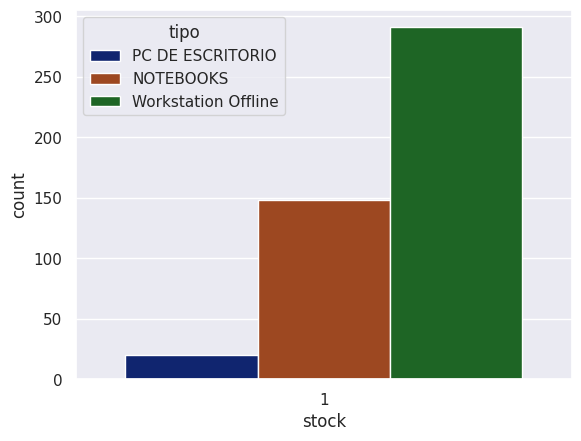

In [ ]:
#grafica simple de los stock

sns.countplot(data=stock,
              x='stock',
              hue='tipo')


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6615 entries, 0 to 10664
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            6615 non-null   object
 1   tipo          6615 non-null   object
 2   marca         6615 non-null   object
 3   modelo        6615 non-null   object
 4   serial        6615 non-null   object
 5   ubicación     6124 non-null   object
 6   dueño         6615 non-null   object
 7   gerencia      5324 non-null   object
 8   departamento  5044 non-null   object
 9   activo_fijo   6615 non-null   object
 10  rfid          6615 non-null   int64 
 11  data_grupo    6615 non-null   object
 12  stock         6615 non-null   int64 
dtypes: int64(2), object(11)
memory usage: 723.5+ KB
